In [60]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# My EDA Analysis

In [61]:
data = pd.read_csv("train.csv")


We need to clean our data first. What I decided to do to clean my data is replace the null values with the median and fill the remaining null values with 0

In [62]:
tenureMed = data['Tenure'].median()
data['Tenure'] = data['Tenure'].replace(np.nan,tenureMed)

data['Support Calls'] = data['Support Calls'].replace("none",0)

data['Support Calls'] = data['Support Calls'].fillna(int(data['Support Calls'].median()))

data['Last Interaction'] = data['Last Interaction'].fillna(data['Last Interaction'].median())

In [63]:
#clean the data by replacing null with 0

clean_data = data.fillna(0)

clean_data.to_csv("clean_data.csv", index=False)


What we see is that the median for the support calls for test is not the same for the training. We also know that if support calls is more than 5 then they are more likely to churn, but null values in the support calls are more likely to not churn.  Therefore, I decided to fill in the missing values in the test data with the median of the training data.

15.0


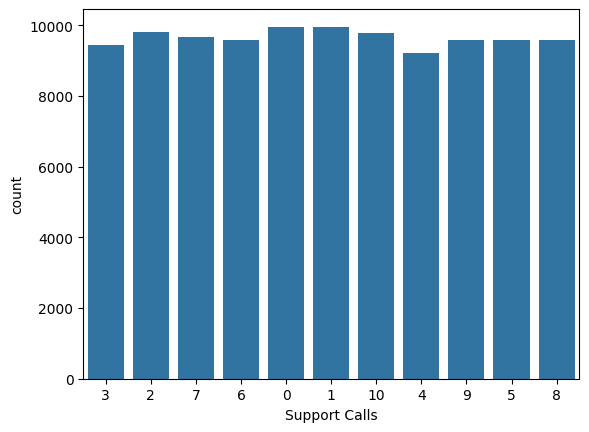

In [64]:
test = pd.read_csv('test.csv')

test['Support Calls'] = test['Support Calls'].replace("none",0)

sns.countplot(data=test,x='Support Calls')
print(test['Last Interaction'].median())



In [65]:
test = pd.read_csv('test.csv')
tenureMed = test['Tenure'].median()

test['Support Calls'] = test['Support Calls'].replace("none",0)
test['Tenure'] = test['Tenure'].replace(np.nan,tenureMed)
test['Support Calls'] = test['Support Calls'].fillna(int(data['Support Calls'].median()))
test['Last Interaction'] = test['Last Interaction'].fillna(test['Last Interaction'].median())
clean_test = test.fillna(0)

clean_test.to_csv("clean_test.csv",index=False)

## Begin EDA

In [66]:
#create a churned and unchurned data set
churned = clean_data[clean_data["Churn"]==1]
unchurned = clean_data[clean_data["Churn"]==0]

<Axes: xlabel='Support Calls', ylabel='count'>

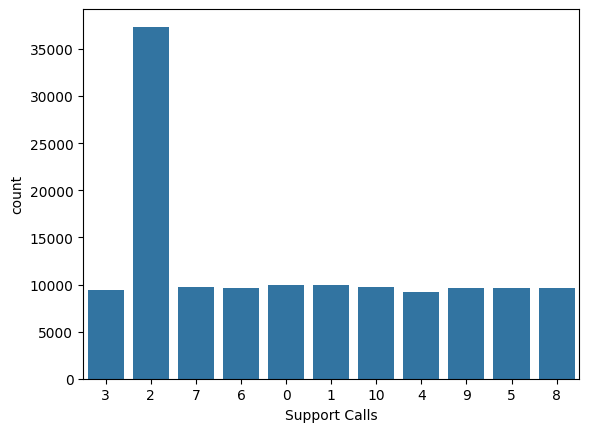

In [67]:
sns.countplot(data=clean_test,x='Support Calls')

<Axes: xlabel='Support Calls', ylabel='count'>

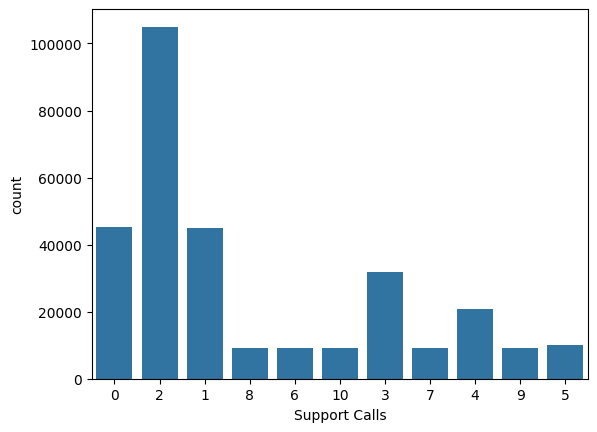

In [68]:
sns.countplot(data=clean_data,x='Support Calls')

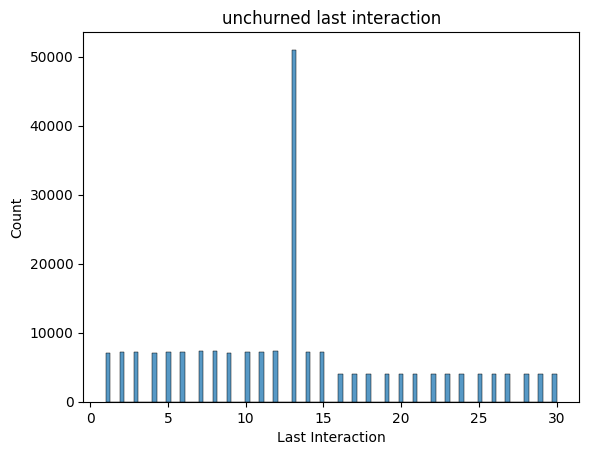

In [69]:
sns.histplot(data=unchurned,x='Last Interaction')
plt.title("unchurned last interaction")
plt.show()

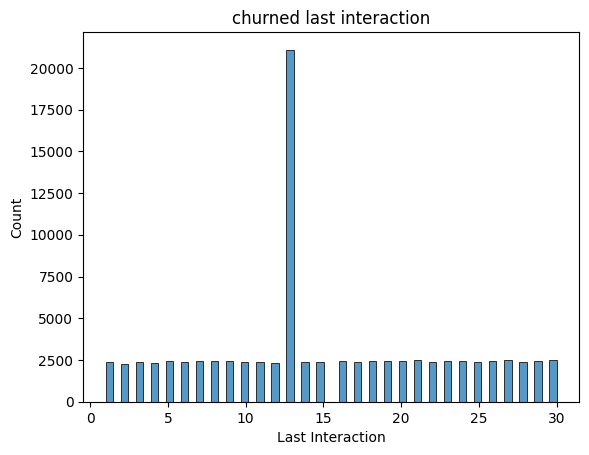

In [70]:
sns.histplot(data=churned,x='Last Interaction')
plt.title("churned last interaction")
plt.show()

#results of both of these show that last interaction does not tend to have a huge relationship between churned and unchurned

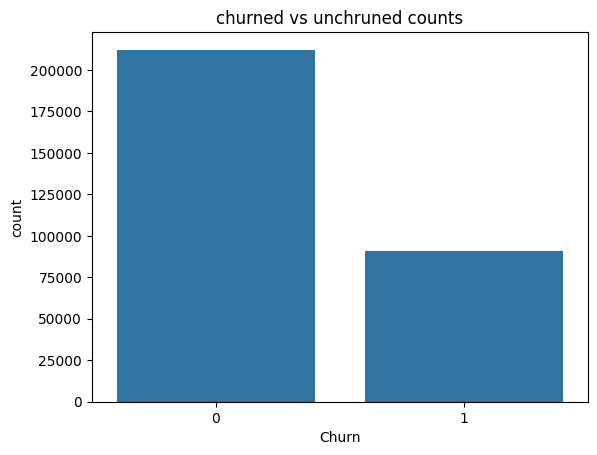

In [71]:
sns.countplot(data=data,x="Churn")
plt.title("churned vs unchruned counts")
plt.show()

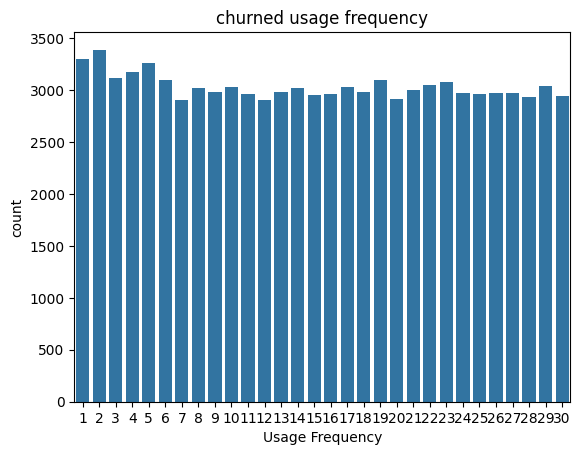

In [72]:
sns.countplot(data=churned,x='Usage Frequency')
plt.title("churned usage frequency")
plt.show()

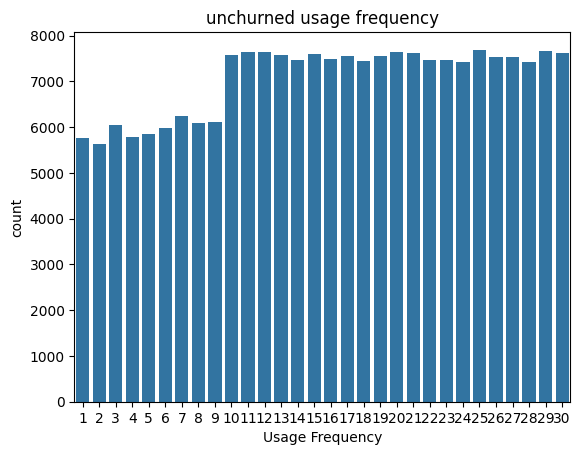

In [73]:
#if you have a low usage frequency you are more likely to churn, for simplicity say usage frequency is less than 9 you are less likely to unchurned
sns.countplot(data=unchurned,x='Usage Frequency')
plt.title("unchurned usage frequency")
plt.show()
#usage frequency could be important

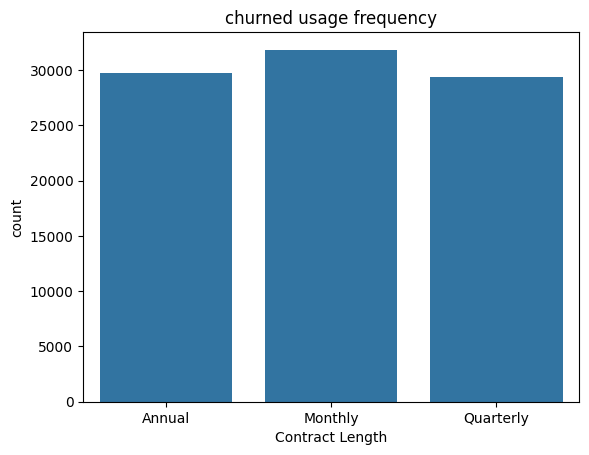

In [74]:
#if you have a monthly contract you are more likely to churn

sns.countplot(data=churned,x='Contract Length')
plt.title("churned usage frequency")
plt.show()

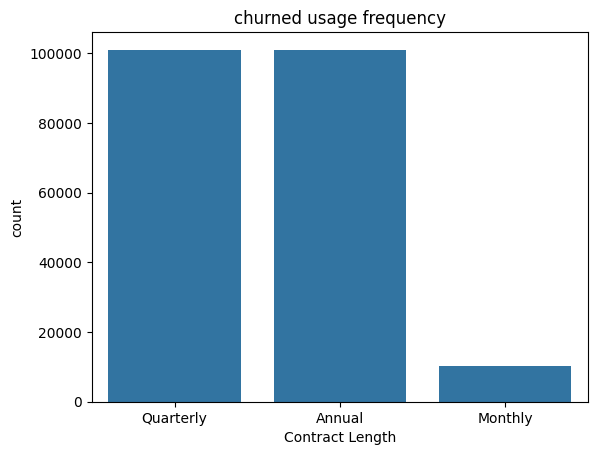

In [75]:
sns.countplot(data=unchurned,x='Contract Length')
plt.title("churned usage frequency")
plt.show()

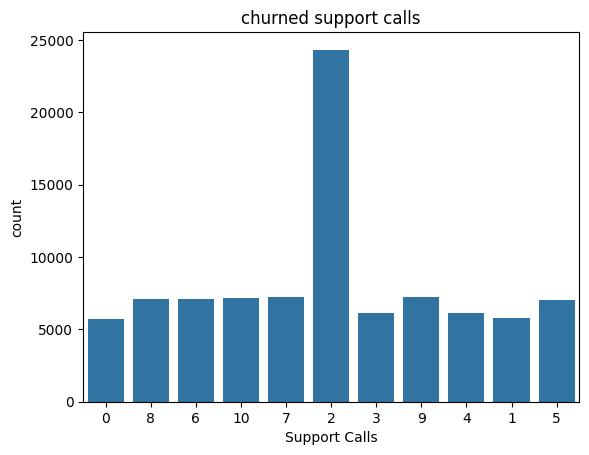

In [76]:
sns.countplot(data=churned,x="Support Calls")
#churned['Support Calls'].value_counts()
plt.title("churned support calls")
plt.show()

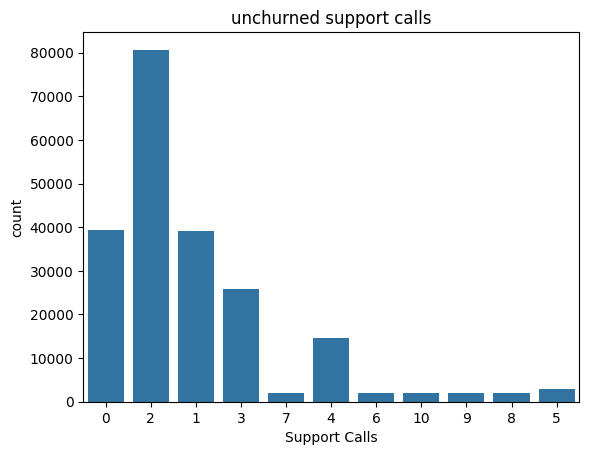

In [77]:
sns.countplot(data=unchurned,x="Support Calls")
plt.title("unchurned support calls")
plt.show()
#if there are a high number of support calls than churn is more likely, could be useful

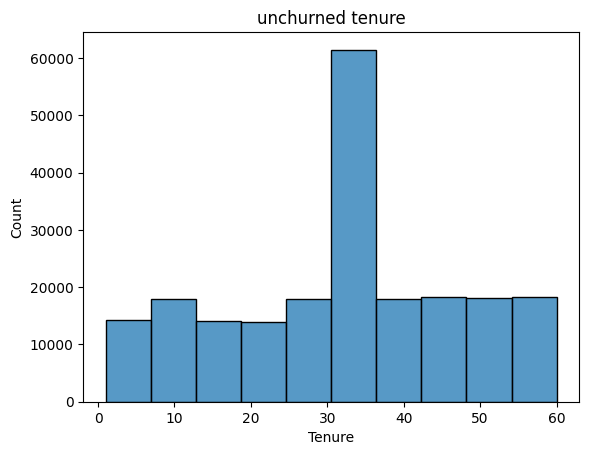

In [78]:
sns.histplot(data=unchurned,x='Tenure',bins=10)
plt.title("unchurned tenure")
plt.show()

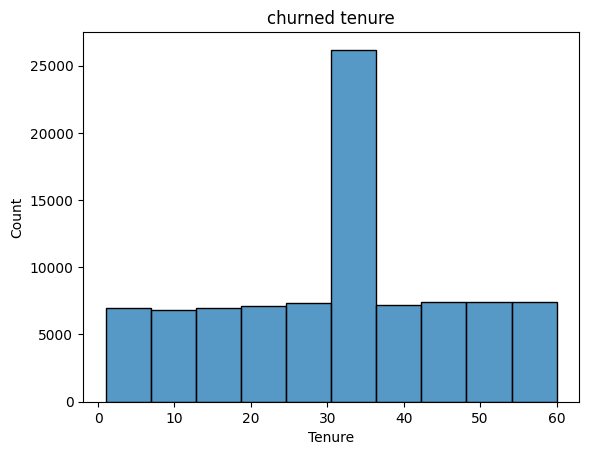

In [79]:
sns.histplot(data=churned,x='Tenure',bins=10)
plt.title("churned tenure")
plt.show()
#tenure doesn't tell us much

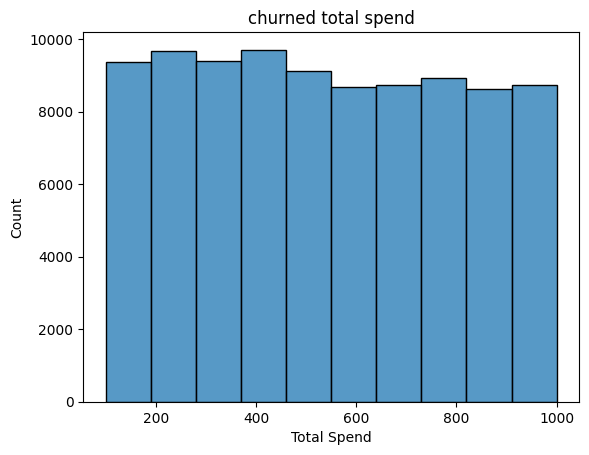

In [80]:
sns.histplot(data=churned,x='Total Spend',bins=10)
plt.title("churned total spend")
plt.show()

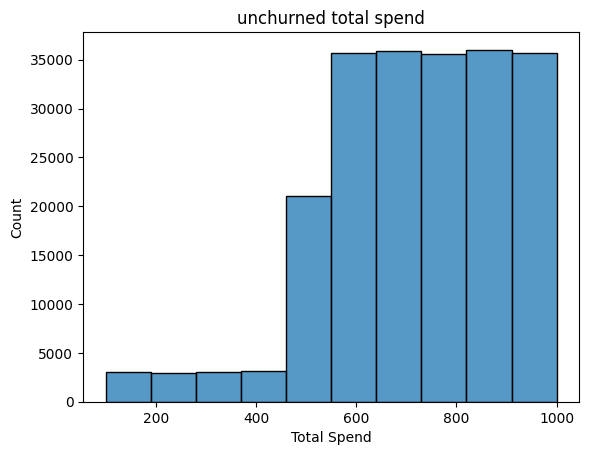

In [81]:
sns.histplot(data=unchurned,x='Total Spend',bins=10)
plt.title("unchurned total spend")
plt.show()
#spend more money, less likely to chrun, total spend is a good category

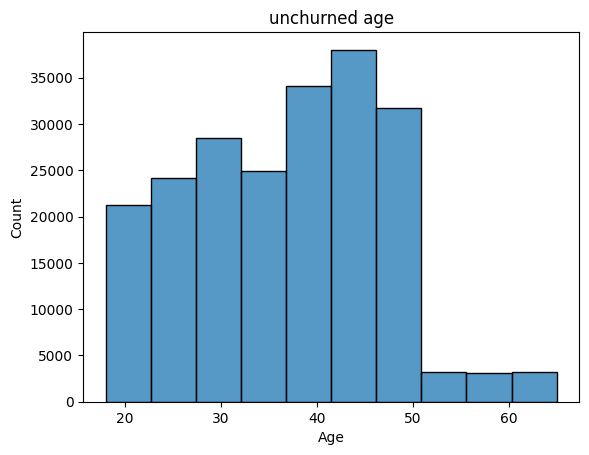

In [82]:
sns.histplot(data=unchurned,x='Age',bins=10)
plt.title("unchurned age")
plt.show()

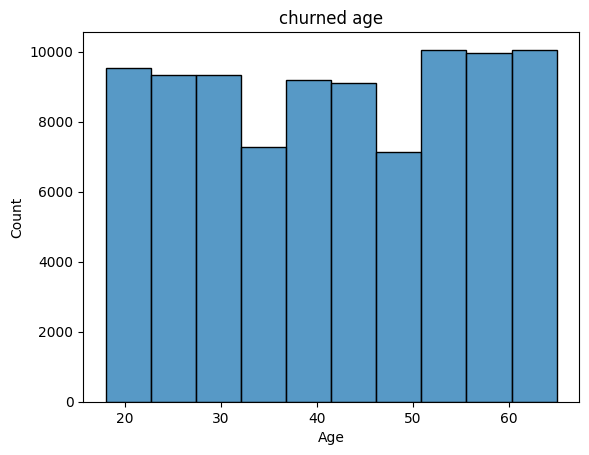

In [83]:
sns.histplot(data=churned,x='Age',bins=10)
plt.title("churned age")
plt.show()
#the younger you are the more likely to not churn, could be a could determiner

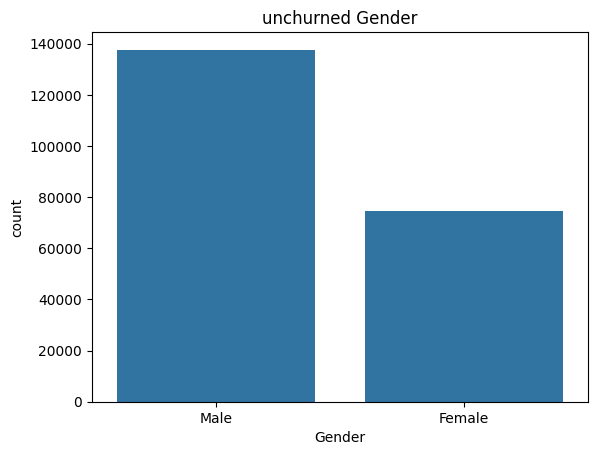

In [84]:
sns.countplot(data=unchurned,x='Gender')
plt.title("unchurned Gender")
plt.show()

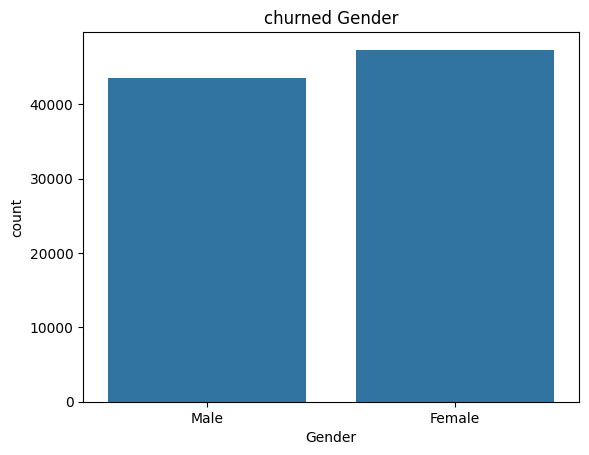

In [85]:
sns.countplot(data=churned,x='Gender')
plt.title("churned Gender")
plt.show()

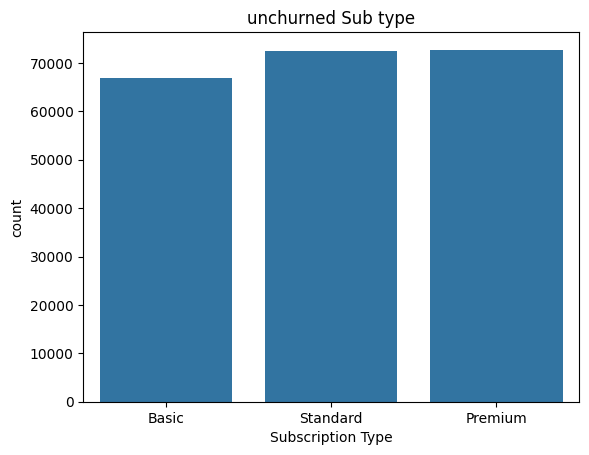

In [86]:
sns.countplot(data=unchurned,x='Subscription Type')
plt.title("unchurned Sub type")
plt.show()

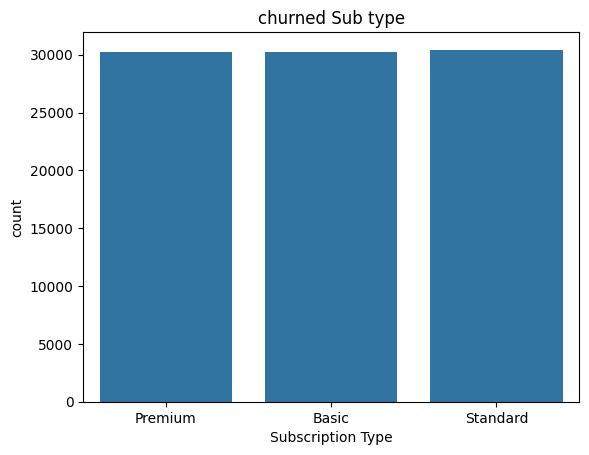

In [87]:
sns.countplot(data=churned,x='Subscription Type')
plt.title("churned Sub type")
plt.show()
#subscription type doesn't tell us much

## My basic EDA model

In [88]:
clean_data[(clean_data['Contract Length']=="Monthly") | (clean_data['Total Spend']<500)|(data['Usage Frequency']<3)]['Churn'].value_counts()


Churn
1    62591
0    29546
Name: count, dtype: int64

In [89]:
from sklearn.model_selection import train_test_split
X = clean_data[['Contract Length','Total Spend','Usage Frequency']]
y = clean_data['Churn']
X_train, X_validation, y_train, y_validation = train_test_split(X,y, test_size=.3, random_state=123)


In [90]:
class_prediction = ((X_train['Contract Length']=="Monthly") | 
                            (X_train['Total Spend']<500) | 
                            (X_train['Usage Frequency']<3)
                           ).astype(int)
class_prediction

267343    1
90073     1
198661    0
241135    1
37600     0
         ..
192476    0
17730     1
28030     0
277869    0
249342    0
Length: 212186, dtype: int64

## How well does my model work?

In [91]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
print(accuracy_score(y_train, class_prediction))
print(precision_score(y_train, class_prediction, zero_division=0))
print(recall_score(y_train, class_prediction))
print(f1_score(y_train, class_prediction))
print(confusion_matrix(y_train,class_prediction))

0.8086443026401365
0.6793358733698851
0.6879126738915639
0.6835973723378557
[[127721  20704]
 [ 19899  43862]]


## Using my model, run the metrics on the test data and then convert it to a csv file

In [92]:
prob = test[["CustomerID"]].copy()

In [93]:
prob['Churn'] = ((test['Contract Length']=="Monthly") | (test['Total Spend']<500)|(test['Usage Frequency']<3)).astype(float)

prob['Churn'].value_counts()



Churn
1.0    85470
0.0    48306
Name: count, dtype: int64

In [94]:
prob.to_csv("prob_eda.csv",index=False)